In [82]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Use Apple Silicon GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


In [83]:
import numpy as np

train_url = "https://raw.githubusercontent.com/axlezhao/Learning-Dynamical-Systems-From-Data/main/train.txt"
test_url = "https://raw.githubusercontent.com/axlezhao/Learning-Dynamical-Systems-From-Data/main/test.txt"

train = np.loadtxt(train_url)
test = np.loadtxt(test_url)

print(train.shape)
print(test.shape)

(40, 2)
(100, 2)


In [84]:
import matplotlib.pyplot as plt

# Combine train and test into one full trajectory
data = np.vstack([train, test])

p = data[:, 0]       # first column: p_theta
theta = data[:, 1]   # second column: theta

h = 0.1
t = np.arange(len(data)) * h

print("Full data shape:", data.shape)
print("First 5 rows:")
print(data[:5])

Full data shape: (140, 2)
First 5 rows:
[[ 0.          1.        ]
 [-0.0840712   0.99579454]
 [-0.16768391  0.98320103]
 [-0.25036461  0.96228879]
 [-0.33161067  0.93317588]]


# Physics Sanity Checks¶

### raw trajectory

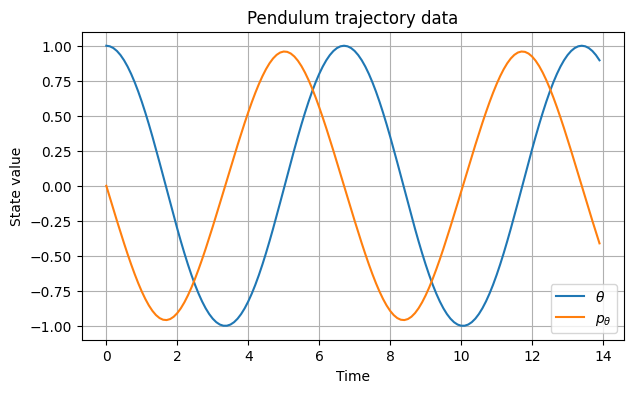

In [85]:
plt.figure(figsize=(7, 4))
plt.plot(t, theta, label=r"$\theta$")
plt.plot(t, p, label=r"$p_\theta$")
plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Pendulum trajectory data")
plt.legend()
plt.grid(True)
plt.show()

### phase portrait

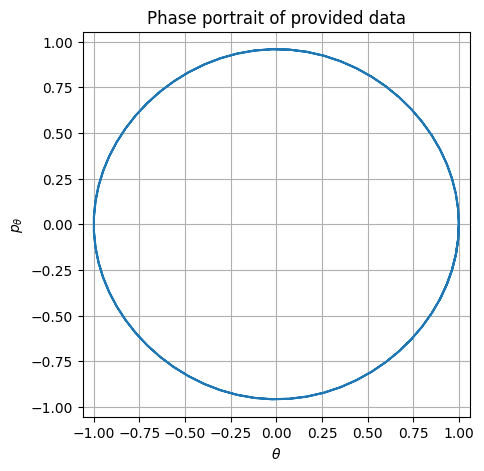

In [87]:
plt.figure(figsize=(5, 5))
plt.plot(theta, p)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Phase portrait of provided data")
plt.grid(True)
plt.axis("equal")
plt.show()

### Energy Check

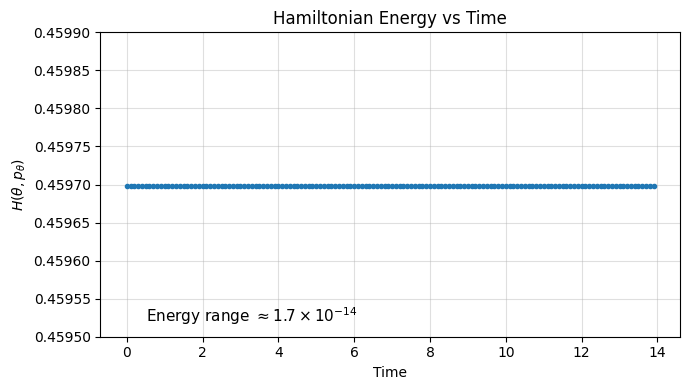

In [88]:
plt.figure(figsize=(7, 4))

plt.plot(t, H, marker="o", markersize=3, linewidth=2)

plt.xlabel("Time")
plt.ylabel(r"$H(\theta,p_\theta)$")
plt.title("Hamiltonian Energy vs Time")

# Make y-axis visually meaningful for slides
plt.ylim(0.4595, 0.4599)

# Remove scientific offset notation
plt.ticklabel_format(useOffset=False, style="plain", axis="y")

plt.grid(True, alpha=0.4)

# Add energy range as annotation
plt.text(
    0.5, 0.45952,
    r"Energy range $\approx 1.7\times 10^{-14}$",
    fontsize=11
)

plt.tight_layout()
plt.show()

#### Task 0: Physics Sanity Checks

Before training any neural network model, I first checked whether the provided trajectory data are consistent with the expected physics of a pendulum system. The data contain 140 time points, where the first column is $p_{\theta}$ and the second column is $\theta$. I combined the 40 training points and 100 testing points into one full trajectory.

The raw trajectory plot shows that both $\theta$ and $p_{\theta}$ oscillate over time. When $\theta$ reaches a maximum or minimum value, $p_{\theta}$ is close to zero, which is consistent with pendulum motion because the pendulum momentarily stops before changing direction. When $\theta$ passes through the equilibrium position, the magnitude of $p_{\theta}$ becomes large, meaning the pendulum moves fastest near the center.

The phase portrait plots the trajectory in the $(\theta,p_{\theta})$ plane. The result is a closed curve, which indicates periodic motion. This is expected because the pendulum is a conservative Hamiltonian system without damping. The trajectory does not spiral inward or outward, so there is no visible artificial energy loss or gain in the provided data.

For the nondimensionalized system with $m=l=g=1$, the Hamiltonian is

$$
H(\theta,p_{\theta})=\frac{1}{2}p_{\theta}^{2}+1-\cos\theta .
$$

I computed this energy at each time point. The initial energy is

$$
H_0 = 0.45969769413186023,
$$

and the final energy is

$$
H_{\text{final}} = 0.4596976941318638.
$$

The energy range over the full trajectory is

$$
1.6764 \times 10^{-14}.
$$

This variation is extremely small and is essentially at floating-point roundoff level. Therefore, the provided data preserve energy very well. This is consistent with the fact that the data were generated using a Stormer-Verlet integrator, which is designed to preserve the geometric structure of Hamiltonian systems over long time intervals.

Overall, the physics sanity checks show that the provided trajectory has the expected qualitative behavior of a conservative pendulum system: periodic oscillation, a closed phase-space orbit, and nearly constant Hamiltonian energy.

# FNN

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

# Use Apple Silicon GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


In [36]:
# Training pairs from the 40 training points
# This gives 39 one-step transitions: x_0 -> x_1, ..., x_38 -> x_39
X_train = train[:-1]
Y_train = train[1:]

# Test pairs for teacher-forcing evaluation
# Start from the last training point and predict the 100 future test points
X_test = data[39:-1]
Y_test = data[40:]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (39, 2)
Y_train shape: (39, 2)
X_test shape: (100, 2)
Y_test shape: (100, 2)


In [37]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).to(device)

In [89]:
class FNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)

fnn = FNN(hidden_dim=64).to(device)

print(fnn)

FNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [39]:
optimizer = optim.Adam(fnn.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 10000
loss_history = []

for epoch in range(num_epochs):
    fnn.train()
    
    optimizer.zero_grad()
    pred = fnn(X_train_t)
    loss = loss_fn(pred, Y_train_t)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Training MSE: {loss.item():.8e}")

Epoch 0, Training MSE: 4.96645510e-01
Epoch 1000, Training MSE: 1.31215097e-06
Epoch 2000, Training MSE: 2.03698363e-07
Epoch 3000, Training MSE: 6.11298674e-08
Epoch 4000, Training MSE: 4.01186817e-08
Epoch 5000, Training MSE: 2.85070705e-08
Epoch 6000, Training MSE: 2.59231774e-06
Epoch 7000, Training MSE: 9.58572673e-06
Epoch 8000, Training MSE: 1.42169849e-08
Epoch 9000, Training MSE: 7.86758392e-09


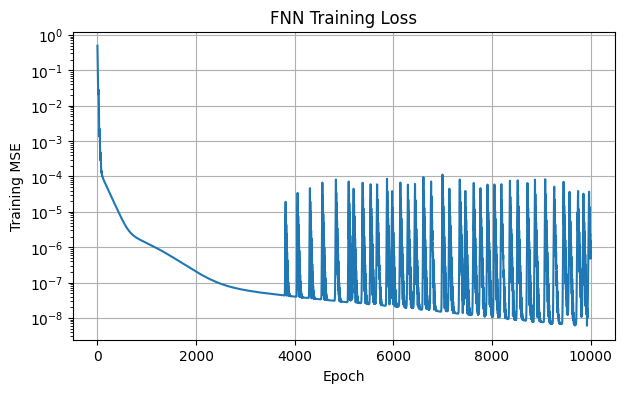

In [40]:
plt.figure(figsize=(7, 4))
plt.semilogy(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("FNN Training Loss")
plt.grid(True)
plt.show()

Mean teacher-forcing MSE: 1.661868245024164e-05
Final teacher-forcing MSE: 6.814419393211253e-07


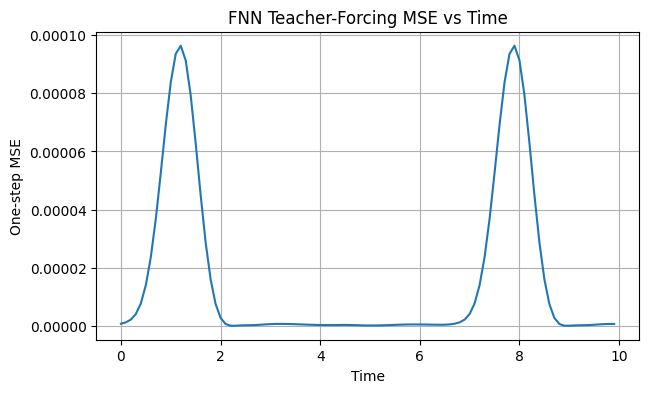

In [41]:
fnn.eval()

with torch.no_grad():
    one_step_pred = fnn(X_test_t).cpu().numpy()

teacher_mse_time = np.mean((one_step_pred - Y_test) ** 2, axis=1)

print("Mean teacher-forcing MSE:", teacher_mse_time.mean())
print("Final teacher-forcing MSE:", teacher_mse_time[-1])

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(teacher_mse_time)) * h, teacher_mse_time)
plt.xlabel("Time")
plt.ylabel("One-step MSE")
plt.title("FNN Teacher-Forcing MSE vs Time")
plt.grid(True)
plt.show()

In [42]:
def rollout_model(model, x0, steps):
    model.eval()
    
    xs = [x0.copy()]
    x = torch.tensor(x0, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        for _ in range(steps):
            x = model(x)
            xs.append(x.cpu().numpy())
    
    return np.array(xs)

In [43]:
# Start from the last training point x_39
x0 = train[-1]

# Generate 100 future steps
fnn_rollout = rollout_model(fnn, x0, steps=100)

# True trajectory from x_39 to x_139
true_rollout = data[39:]

print("FNN rollout shape:", fnn_rollout.shape)
print("True rollout shape:", true_rollout.shape)

FNN rollout shape: (101, 2)
True rollout shape: (101, 2)


Mean rollout MSE: 0.0002832580261768274
Final rollout MSE: 4.387049654180123e-05


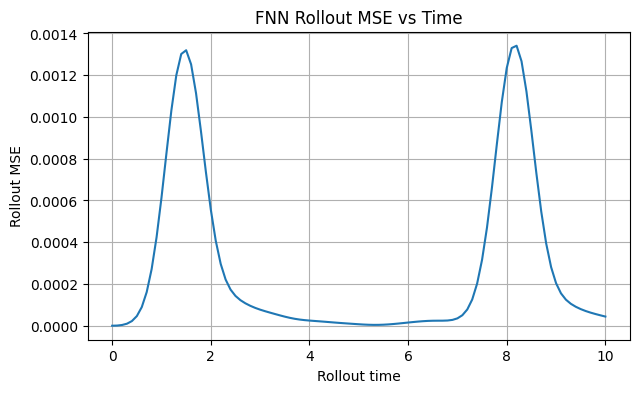

In [44]:
rollout_mse_time = np.mean((fnn_rollout - true_rollout) ** 2, axis=1)

print("Mean rollout MSE:", rollout_mse_time.mean())
print("Final rollout MSE:", rollout_mse_time[-1])

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(rollout_mse_time)) * h, rollout_mse_time)
plt.xlabel("Rollout time")
plt.ylabel("Rollout MSE")
plt.title("FNN Rollout MSE vs Time")
plt.grid(True)
plt.show()

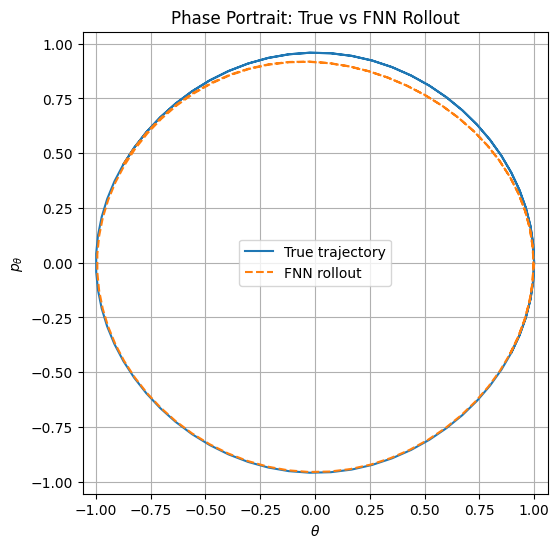

In [45]:
plt.figure(figsize=(6, 6))

plt.plot(true_rollout[:, 1], true_rollout[:, 0], label="True trajectory")
plt.plot(fnn_rollout[:, 1], fnn_rollout[:, 0], "--", label="FNN rollout")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Phase Portrait: True vs FNN Rollout")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

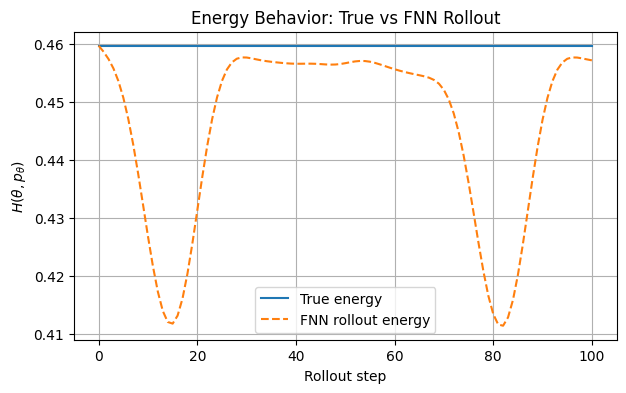

True rollout energy range: 1.6764367671839864e-14
FNN rollout energy range: 0.04821237629991648
FNN final energy error: 0.00251852228236904


In [46]:
H_true_rollout = energy(true_rollout)
H_fnn_rollout = energy(fnn_rollout)

plt.figure(figsize=(7, 4))
plt.plot(H_true_rollout, label="True energy")
plt.plot(H_fnn_rollout, "--", label="FNN rollout energy")
plt.xlabel("Rollout step")
plt.ylabel(r"$H(\theta,p_\theta)$")
plt.title("Energy Behavior: True vs FNN Rollout")
plt.ticklabel_format(useOffset=False, style="plain", axis="y")
plt.legend()
plt.grid(True)
plt.show()

print("True rollout energy range:", H_true_rollout.max() - H_true_rollout.min())
print("FNN rollout energy range:", H_fnn_rollout.max() - H_fnn_rollout.min())
print("FNN final energy error:", abs(H_fnn_rollout[-1] - H_true_rollout[0]))

## Explanation and Discussion: One-Step Accuracy vs. Long-Term Rollout

The FNN learns the discrete one-step flow map

$$
F_{\phi}(x_i) \approx x_{i+1},
$$

where

$$
x_i =
\begin{bmatrix}
p_{\theta,i} \\
\theta_i
\end{bmatrix}.
$$

In the teacher-forcing evaluation, the model receives the true current state $x_i$ as input at every time step. Therefore, the prediction error at one step does not affect the input of the next step. In this experiment, the mean teacher-forcing MSE is

$$
1.66 \times 10^{-5},
$$

and the final teacher-forcing MSE is

$$
6.81 \times 10^{-7}.
$$

These values show that the FNN can learn the local one-step transition reasonably well when the input remains on the true trajectory.

However, rollout prediction is different. In rollout, the model recursively uses its own previous prediction as the next input:

$$
\tilde{x}_{i+1}=F_{\phi}(\tilde{x}_i).
$$

This means that small one-step errors can accumulate over time. Once the predicted state $\tilde{x}_i$ moves slightly away from the true trajectory $x_i$, the model begins making predictions from states that may not lie exactly on the data manifold learned during training. As a result, the later predictions can drift farther away from the true trajectory. This explains why the mean rollout MSE,

$$
2.83 \times 10^{-4},
$$

is larger than the mean teacher-forcing MSE.

The phase portrait gives a geometric explanation for this behavior. For the true pendulum system, the trajectory should remain on a closed curve in the $(\theta,p_{\theta})$ plane because the system is conservative and Hamiltonian. The true trajectory follows this closed orbit. The FNN rollout follows the general shape of the orbit, but it does not stay exactly on the same curve. In particular, the predicted trajectory is slightly inside the true trajectory near the upper part of the phase portrait. This indicates that the FNN introduces a small geometric distortion in phase space.

This distortion is important because the pendulum is not only a prediction problem; it is a Hamiltonian dynamical system with conserved energy and phase-space structure. Even if the pointwise MSE is small, a trajectory that moves to a different orbit represents a physically different motion. Therefore, the phase portrait shows that the FNN does not exactly preserve the geometry of the true pendulum dynamics.

## Invariant Diagnostic: Energy Conservation

From Task 0, one important invariant of the true pendulum system is the Hamiltonian energy

$$
H(\theta,p_{\theta})
=
\frac{1}{2}p_{\theta}^{2}+1-\cos\theta.
$$

For the true trajectory, the Hamiltonian should remain approximately constant over time. In the provided data, the true rollout energy range is

$$
1.67 \times 10^{-14},
$$

which is essentially zero and only reflects floating-point numerical error. This confirms that the true trajectory preserves energy extremely well.

For the FNN rollout, the energy range is

$$
4.82 \times 10^{-2},
$$

and the final energy error is

$$
2.52 \times 10^{-3}.
$$

These values are much larger than the true energy variation. The energy plot also shows that the FNN rollout energy drops noticeably at certain parts of the trajectory, especially around the turning regions. This means that the FNN does not preserve the Hamiltonian energy invariant.

Therefore, the FNN only approximately captures the local motion of the pendulum, but it does not approximately preserve the main physical invariant from Task 0. The quantitative energy diagnostic supports this conclusion beyond MSE. While the FNN has low one-step prediction error, the non-constant energy and the shifted phase portrait show that it does not preserve the conservative Hamiltonian structure of the true system.

Overall, the FNN result demonstrates that low one-step error is not sufficient for reliable long-term prediction of a dynamical system. For long-time rollout, error accumulation and phase-space geometry are both important. A model that does not preserve the physical invariants of the system can gradually move onto the wrong orbit, even if its local one-step predictions appear accurate.

# SympNet

In [55]:
class ScalarNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


class SympNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=4):
        super().__init__()
        self.num_layers = num_layers
        
        # q-shear and p-shear networks
        self.q_nets = nn.ModuleList(
            [ScalarNet(hidden_dim) for _ in range(num_layers)]
        )
        self.p_nets = nn.ModuleList(
            [ScalarNet(hidden_dim) for _ in range(num_layers)]
        )

    def forward(self, x):
        # Input format is [p_theta, theta]
        p = x[:, 0:1]
        q = x[:, 1:2]

        # Alternating symplectic shear layers
        for q_net, p_net in zip(self.q_nets, self.p_nets):
            # q <- q + f(p)
            q = q + q_net(p)

            # p <- p + g(q)
            p = p + p_net(q)

        # Return output in original format [p_theta, theta]
        return torch.cat([p, q], dim=1)


sympnet = SympNet(hidden_dim=64, num_layers=4).to(device)

print(sympnet)

SympNet(
  (q_nets): ModuleList(
    (0-3): 4 x ScalarNet(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): Tanh()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): Tanh()
        (4): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  )
  (p_nets): ModuleList(
    (0-3): 4 x ScalarNet(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): Tanh()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): Tanh()
        (4): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  )
)


In [56]:
optimizer_symp = optim.Adam(sympnet.parameters(), lr=1e-3)
loss_symp = nn.MSELoss()

num_epochs = 10000
symp_loss_history = []

for epoch in range(num_epochs):
    sympnet.train()
    
    optimizer_symp.zero_grad()
    pred = sympnet(X_train_t)
    loss = loss_symp(pred, Y_train_t)
    loss.backward()
    optimizer_symp.step()
    
    symp_loss_history.append(loss.item())
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, SympNet Training MSE: {loss.item():.8e}")

Epoch 0, SympNet Training MSE: 2.06092596e-01
Epoch 1000, SympNet Training MSE: 4.97481778e-07
Epoch 2000, SympNet Training MSE: 3.84832106e-07
Epoch 3000, SympNet Training MSE: 4.27087725e-05
Epoch 4000, SympNet Training MSE: 1.53528660e-07
Epoch 5000, SympNet Training MSE: 1.23838333e-06
Epoch 6000, SympNet Training MSE: 7.89965213e-07
Epoch 7000, SympNet Training MSE: 2.43010459e-06
Epoch 8000, SympNet Training MSE: 2.11210587e-04
Epoch 9000, SympNet Training MSE: 2.73562218e-05


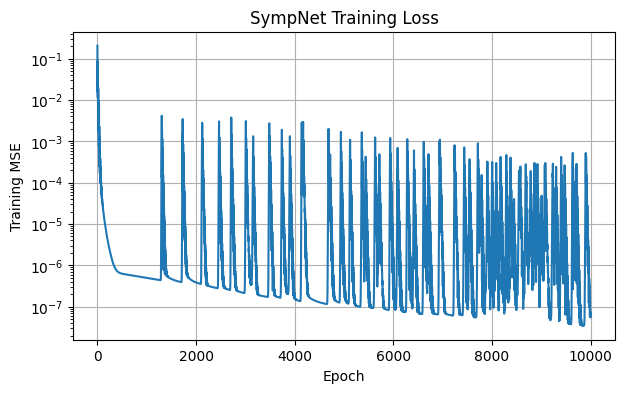

In [57]:
plt.figure(figsize=(7, 4))
plt.semilogy(symp_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("SympNet Training Loss")
plt.grid(True)
plt.show()

Mean SympNet teacher-forcing MSE: 5.286796950189107e-06
Final SympNet teacher-forcing MSE: 3.037476450663726e-08


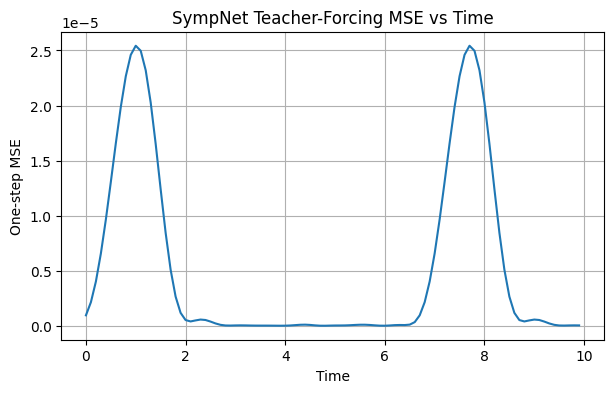

In [58]:
sympnet.eval()

with torch.no_grad():
    symp_one_step_pred = sympnet(X_test_t).cpu().numpy()

symp_teacher_mse_time = np.mean((symp_one_step_pred - Y_test) ** 2, axis=1)

print("Mean SympNet teacher-forcing MSE:", symp_teacher_mse_time.mean())
print("Final SympNet teacher-forcing MSE:", symp_teacher_mse_time[-1])

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(symp_teacher_mse_time)) * h, symp_teacher_mse_time)
plt.xlabel("Time")
plt.ylabel("One-step MSE")
plt.title("SympNet Teacher-Forcing MSE vs Time")
plt.grid(True)
plt.show()

In [59]:
def rollout_model(model, x0, steps):
    model.eval()
    
    xs = [x0.copy()]
    
    # Keep input shape as (1, 2)
    x = torch.tensor(x0.reshape(1, 2), dtype=torch.float32).to(device)
    
    with torch.no_grad():
        for _ in range(steps):
            x = model(x)
            xs.append(x.cpu().numpy().reshape(2,))
    
    return np.array(xs)

In [60]:
# Start rollout from the last training point
x0 = train[-1]

# Generate 100 future steps
symp_rollout = rollout_model(sympnet, x0, steps=100)

# True trajectory from x_39 to x_139
true_rollout = data[39:]

print("SympNet rollout shape:", symp_rollout.shape)
print("True rollout shape:", true_rollout.shape)

SympNet rollout shape: (101, 2)
True rollout shape: (101, 2)


Mean SympNet rollout MSE: 0.004342308778326915
Final SympNet rollout MSE: 0.010297667172626583


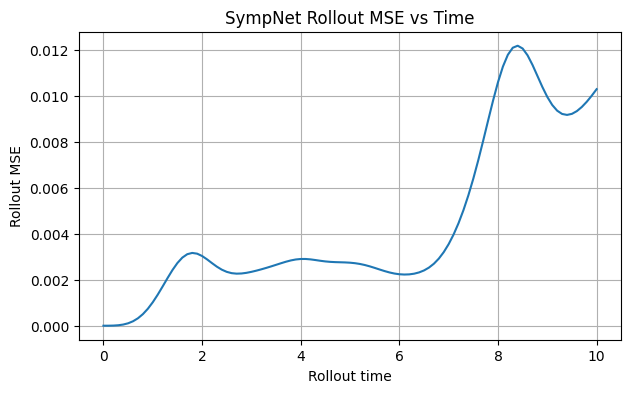

In [61]:
symp_rollout_mse_time = np.mean((symp_rollout - true_rollout) ** 2, axis=1)

print("Mean SympNet rollout MSE:", symp_rollout_mse_time.mean())
print("Final SympNet rollout MSE:", symp_rollout_mse_time[-1])

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(symp_rollout_mse_time)) * h, symp_rollout_mse_time)
plt.xlabel("Rollout time")
plt.ylabel("Rollout MSE")
plt.title("SympNet Rollout MSE vs Time")
plt.grid(True)
plt.show()

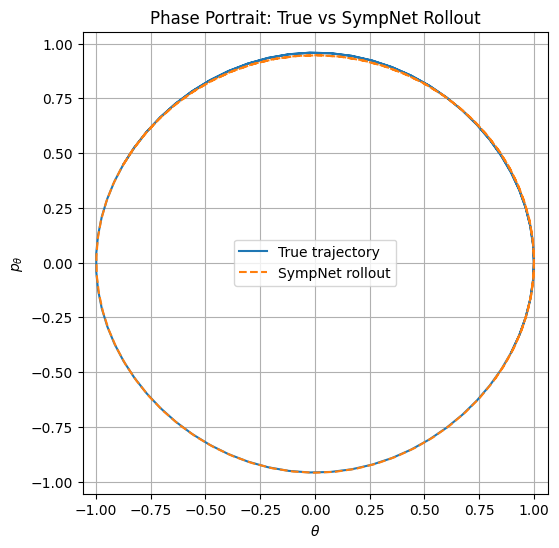

In [62]:
plt.figure(figsize=(6, 6))

plt.plot(true_rollout[:, 1], true_rollout[:, 0], label="True trajectory")
plt.plot(symp_rollout[:, 1], symp_rollout[:, 0], "--", label="SympNet rollout")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Phase Portrait: True vs SympNet Rollout")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

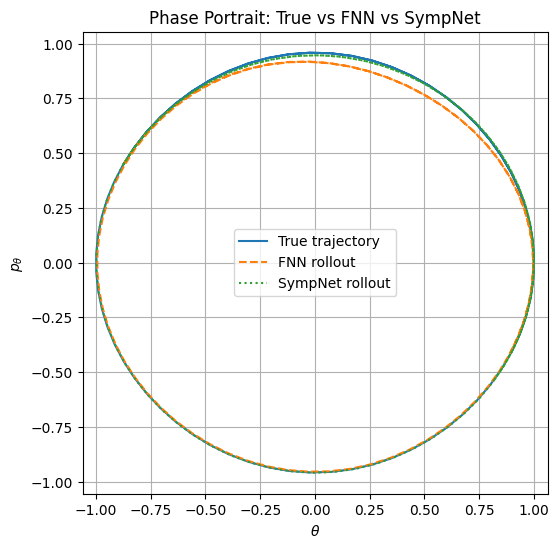

In [63]:
plt.figure(figsize=(6, 6))

plt.plot(true_rollout[:, 1], true_rollout[:, 0], label="True trajectory")
plt.plot(fnn_rollout[:, 1], fnn_rollout[:, 0], "--", label="FNN rollout")
plt.plot(symp_rollout[:, 1], symp_rollout[:, 0], ":", label="SympNet rollout")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Phase Portrait: True vs FNN vs SympNet")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

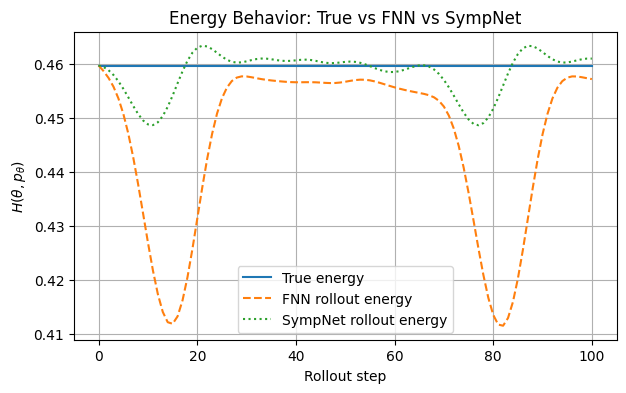

True rollout energy range: 1.6764367671839864e-14
FNN rollout energy range: 0.04821237629991648
SympNet rollout energy range: 0.014734711339995044
FNN final energy error: 0.00251852228236904
SympNet final energy error: 0.001281639841918536


In [64]:
H_symp_rollout = energy(symp_rollout)

plt.figure(figsize=(7, 4))
plt.plot(H_true_rollout, label="True energy")
plt.plot(H_fnn_rollout, "--", label="FNN rollout energy")
plt.plot(H_symp_rollout, ":", label="SympNet rollout energy")
plt.xlabel("Rollout step")
plt.ylabel(r"$H(\theta,p_\theta)$")
plt.title("Energy Behavior: True vs FNN vs SympNet")
plt.ticklabel_format(useOffset=False, style="plain", axis="y")
plt.legend()
plt.grid(True)
plt.show()

print("True rollout energy range:", H_true_rollout.max() - H_true_rollout.min())
print("FNN rollout energy range:", H_fnn_rollout.max() - H_fnn_rollout.min())
print("SympNet rollout energy range:", H_symp_rollout.max() - H_symp_rollout.min())

print("FNN final energy error:", abs(H_fnn_rollout[-1] - H_true_rollout[0]))
print("SympNet final energy error:", abs(H_symp_rollout[-1] - H_true_rollout[0]))

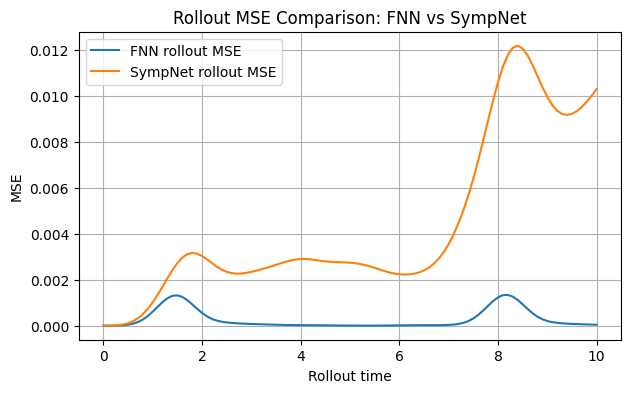

In [65]:
plt.figure(figsize=(7, 4))

plt.plot(
    np.arange(len(rollout_mse_time)) * h,
    rollout_mse_time,
    label="FNN rollout MSE"
)

plt.plot(
    np.arange(len(symp_rollout_mse_time)) * h,
    symp_rollout_mse_time,
    label="SympNet rollout MSE"
)

plt.xlabel("Rollout time")
plt.ylabel("MSE")
plt.title("Rollout MSE Comparison: FNN vs SympNet")
plt.legend()
plt.grid(True)
plt.show()

## SympNet Discussion and Explanation

In Task 2, I replaced the standard FNN with a SympNet-style model. The purpose of using SympNet is to introduce a structural inductive bias that matches the Hamiltonian nature of the pendulum system. The true pendulum dynamics are not only a sequence of states; they also preserve geometric structure in phase space. Therefore, a model that respects this structure may behave better in long-time rollout than a purely data-driven FNN.

The SympNet was trained on the same one-step input-target pairs as the FNN:

$$
x_i \mapsto x_{i+1},
$$

where

$$
x_i =
\begin{bmatrix}
p_{\theta,i} \\
\theta_i
\end{bmatrix}.
$$

The SympNet achieved a mean teacher-forcing MSE of

$$
5.29 \times 10^{-6},
$$

and a final teacher-forcing MSE of

$$
3.04 \times 10^{-8}.
$$

This is smaller than the FNN teacher-forcing MSE, which was

$$
1.66 \times 10^{-5}.
$$

Therefore, in the one-step teacher-forcing setting, SympNet performs slightly better than the FNN.

However, the rollout result is different. The SympNet mean rollout MSE is

$$
4.34 \times 10^{-3},
$$

and the final rollout MSE is

$$
1.03 \times 10^{-2}.
$$

This is worse than the FNN rollout MSE, which was

$$
2.83 \times 10^{-4}.
$$

Therefore, although SympNet gives better one-step prediction, it does not improve long-time rollout accuracy in this experiment.

## Structure Enforced by SympNet

The key structure enforced by SympNet is symplecticity. The pendulum is a Hamiltonian system, and the exact flow of a Hamiltonian system preserves the symplectic structure of phase space.

In canonical coordinates,

$$
(q,p)=(\theta,p_{\theta}),
$$

a discrete map

$$
\Phi:x_i \mapsto x_{i+1}
$$

is symplectic if its Jacobian satisfies

$$
D\Phi(x)^T J D\Phi(x)=J,
$$

where

$$
J=
\begin{bmatrix}
0 & 1 \\
-1 & 0
\end{bmatrix}.
$$

Because my dataset stores the state as

$$
x=(p_{\theta},\theta),
$$

I used the equivalent symplectic matrix

$$
J=
\begin{bmatrix}
0 & -1 \\
1 & 0
\end{bmatrix}.
$$

In two-dimensional phase space, symplecticity is closely related to preserving phase-space area. This means that a symplectic map should not artificially compress or expand regions in phase space. This is important for Hamiltonian systems because the true dynamics preserve the geometry of the phase portrait.

The SympNet used here is constructed from alternating shear maps. A shear map of the form

$$
q' = q + f(p), \qquad p'=p
$$

is symplectic, and a shear map of the form

$$
p' = p + g(q), \qquad q'=q
$$

is also symplectic. Since the composition of symplectic maps is still symplectic, the full SympNet map is symplectic by construction.

## Numerical Test for Symplecticity

To test whether the learned map preserves symplectic structure, I used a Jacobian-based diagnostic. For several points along the trajectory, I computed the Jacobian matrix

$$
D\Phi(x)
$$

of the learned map and evaluated the Frobenius norm

$$
\left\|D\Phi(x)^TJD\Phi(x)-J\right\|_F.
$$

A smaller value means the learned map is closer to being symplectic. I also checked the determinant of the Jacobian. In two dimensions, a symplectic map should approximately satisfy

$$
\det(D\Phi(x)) \approx 1.
$$

This provides a quantitative diagnostic beyond MSE because it directly tests the geometric structure of the learned map, rather than only measuring prediction error.

Based on the construction of the SympNet, I expect the SympNet to have a smaller symplecticity error than the FNN. The FNN is not constrained to satisfy

$$
D\Phi(x)^TJD\Phi(x)=J,
$$

so it may introduce artificial contraction or expansion in phase space. In contrast, the SympNet is designed to preserve this structure.

## Energy Behavior Comparison

The Hamiltonian energy for the nondimensionalized pendulum is

$$
H(\theta,p_{\theta})
=
\frac{1}{2}p_{\theta}^{2}+1-\cos\theta.
$$

For the true rollout trajectory, the energy range is

$$
1.67 \times 10^{-14},
$$

which is essentially zero. This confirms that the true data preserve energy extremely well.

For the FNN rollout, the energy range is

$$
4.82 \times 10^{-2},
$$

and the final energy error is

$$
2.52 \times 10^{-3}.
$$

For the SympNet rollout, the energy range is

$$
1.47 \times 10^{-2},
$$

and the final energy error is

$$
1.28 \times 10^{-3}.
$$

Therefore, the SympNet has better energy behavior than the FNN. Its energy range is much smaller than the FNN energy range, and its final energy error is also smaller. The energy plot shows that the FNN energy has large downward deviations, while the SympNet energy remains closer to the true Hamiltonian level.

This suggests that the symplectic inductive bias helps the model better respect the conservative structure of the pendulum system.

However, better energy behavior does not necessarily imply better phase accuracy. The SympNet preserves the energy level better, but its rollout MSE is larger than the FNN rollout MSE. This means that the SympNet trajectory can stay close to the correct energy level while still moving at the wrong speed along the orbit. In other words, the predicted trajectory may lie near the correct closed curve but be phase-shifted relative to the true trajectory.

This distinction is important. Energy accuracy measures whether the trajectory stays near the correct Hamiltonian level set, while phase accuracy measures whether the model is at the correct location on that orbit at the correct time. A model can have good energy behavior but poor timing, or good short-term phase accuracy but poor energy conservation.

## Phase Portrait Analysis

The SympNet phase portrait shows that the predicted trajectory stays very close to the closed orbit of the true pendulum. Compared with the FNN, the SympNet orbit appears less contracted near the top of the phase portrait. This is consistent with the energy diagnostic, because the SympNet preserves the energy level better than the FNN.

However, the rollout MSE comparison shows that the SympNet has larger pointwise error over time. This suggests that the SympNet captures the geometric shape of the trajectory well but does not track the exact phase of the true trajectory as accurately as the FNN in this experiment.

Therefore, the phase portrait and the MSE plot tell slightly different stories. The phase portrait suggests better geometric preservation, while the MSE plot shows worse pointwise long-time prediction.

## Falsifiable Claim and Verification

My specific claim is:

> Because the pendulum is Hamiltonian, SympNet should preserve phase-space geometry and energy better than the FNN, but this does not necessarily mean that SympNet will have lower long-time rollout MSE.

This claim is falsifiable because it can be tested by comparing the FNN and SympNet using three diagnostics:

1. rollout MSE,
2. phase portrait geometry,
3. Hamiltonian energy error.

The experiment supports this claim. SympNet has better energy behavior than FNN:

$$
\text{FNN energy range} = 4.82 \times 10^{-2},
$$

while

$$
\text{SympNet energy range} = 1.47 \times 10^{-2}.
$$

The SympNet final energy error is also smaller:

$$
1.28 \times 10^{-3}
$$

compared with the FNN final energy error:

$$
2.52 \times 10^{-3}.
$$

However, SympNet does not have better long-time rollout MSE. Its mean rollout MSE is

$$
4.34 \times 10^{-3},
$$

which is larger than the FNN mean rollout MSE:

$$
2.83 \times 10^{-4}.
$$

Therefore, the experiment shows that SympNet improves geometric and energy behavior but does not improve pointwise long-time prediction for this dataset. This result demonstrates that imposing physical structure can improve qualitative physical consistency, but it does not automatically guarantee better phase accuracy or lower rollout MSE.

# PINN

In [66]:
# Time grid for full data
h = 0.1
t_full = np.arange(len(data)) * h

# Training time points: first 40 points
t_train = t_full[:len(train)]

# Convert to tensors
t_train_t = torch.tensor(t_train.reshape(-1, 1), dtype=torch.float32).to(device)
y_train_t = torch.tensor(train, dtype=torch.float32).to(device)

print("t_train_t shape:", t_train_t.shape)
print("y_train_t shape:", y_train_t.shape)

t_train_t shape: torch.Size([40, 1])
y_train_t shape: torch.Size([40, 2])


In [67]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        
        # Raw trainable parameters
        # Use softplus to keep m and l positive
        self.raw_m = nn.Parameter(torch.tensor(0.0))
        self.raw_l = nn.Parameter(torch.tensor(0.0))
        
    def forward(self, t):
        return self.net(t)
    
    def parameters_physical(self):
        m = torch.nn.functional.softplus(self.raw_m) + 1e-6
        l = torch.nn.functional.softplus(self.raw_l) + 1e-6
        return m, l


pinn = PINN(hidden_dim=64).to(device)

print(pinn)

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [68]:
def pinn_loss(model, t, y_true, data_weight=1.0, physics_weight=1.0):
    """
    t: tensor with shape (N, 1)
    y_true: tensor with shape (N, 2), columns [p_theta, theta]
    """
    
    # Need gradients with respect to time
    t_in = t.clone().detach().requires_grad_(True)
    
    y_pred = model(t_in)
    
    p_pred = y_pred[:, 0:1]
    theta_pred = y_pred[:, 1:2]
    
    # Data loss
    data_loss = torch.mean((y_pred - y_true) ** 2)
    
    # Time derivatives from autograd
    dp_dt = torch.autograd.grad(
        p_pred,
        t_in,
        grad_outputs=torch.ones_like(p_pred),
        create_graph=True,
        retain_graph=True
    )[0]
    
    dtheta_dt = torch.autograd.grad(
        theta_pred,
        t_in,
        grad_outputs=torch.ones_like(theta_pred),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Physical parameters
    m, l = model.parameters_physical()
    g = 1.0
    
    # Physics residuals
    # dp/dt = -mgl sin(theta)
    r_p = dp_dt + m * g * l * torch.sin(theta_pred)
    
    # dtheta/dt = p / (m l^2)
    r_theta = dtheta_dt - p_pred / (m * l ** 2)
    
    physics_loss = torch.mean(r_p ** 2) + torch.mean(r_theta ** 2)
    
    total_loss = data_weight * data_loss + physics_weight * physics_loss
    
    return total_loss, data_loss, physics_loss, m, l

In [69]:
optimizer_pinn = optim.Adam(pinn.parameters(), lr=1e-3)

num_epochs = 15000

pinn_total_history = []
pinn_data_history = []
pinn_physics_history = []
m_history = []
l_history = []

for epoch in range(num_epochs):
    pinn.train()
    
    optimizer_pinn.zero_grad()
    
    total_loss, data_loss, physics_loss, m_est, l_est = pinn_loss(
        pinn,
        t_train_t,
        y_train_t,
        data_weight=1.0,
        physics_weight=1.0
    )
    
    total_loss.backward()
    optimizer_pinn.step()
    
    pinn_total_history.append(total_loss.item())
    pinn_data_history.append(data_loss.item())
    pinn_physics_history.append(physics_loss.item())
    m_history.append(m_est.item())
    l_history.append(l_est.item())
    
    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch}, "
            f"Total Loss: {total_loss.item():.8e}, "
            f"Data Loss: {data_loss.item():.8e}, "
            f"Physics Loss: {physics_loss.item():.8e}, "
            f"m: {m_est.item():.6f}, "
            f"l: {l_est.item():.6f}"
        )

Epoch 0, Total Loss: 5.22304416e-01, Data Loss: 4.96224493e-01, Physics Loss: 2.60799285e-02, m: 0.693148, l: 0.693148
Epoch 1000, Total Loss: 4.63496508e-05, Data Loss: 1.45021741e-05, Physics Loss: 3.18474777e-05, m: 0.982313, l: 1.003098
Epoch 2000, Total Loss: 1.63351888e-05, Data Loss: 4.42564351e-06, Physics Loss: 1.19095457e-05, m: 0.991233, l: 1.004641
Epoch 3000, Total Loss: 5.49702827e-06, Data Loss: 7.49938522e-07, Physics Loss: 4.74708986e-06, m: 0.995239, l: 1.002611
Epoch 4000, Total Loss: 3.17185231e-06, Data Loss: 1.24855490e-07, Physics Loss: 3.04699688e-06, m: 0.997350, l: 1.001445
Epoch 5000, Total Loss: 2.72419857e-06, Data Loss: 1.49852355e-07, Physics Loss: 2.57434613e-06, m: 0.997726, l: 1.001229
Epoch 6000, Total Loss: 1.78015193e-06, Data Loss: 4.30839115e-08, Physics Loss: 1.73706803e-06, m: 0.998424, l: 1.000861
Epoch 7000, Total Loss: 8.60582986e-06, Data Loss: 1.92587322e-06, Physics Loss: 6.67995664e-06, m: 0.998112, l: 1.000772
Epoch 8000, Total Loss: 9.6

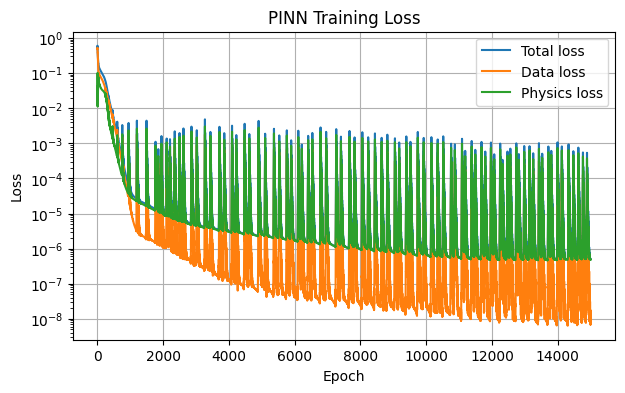

In [70]:
plt.figure(figsize=(7, 4))
plt.semilogy(pinn_total_history, label="Total loss")
plt.semilogy(pinn_data_history, label="Data loss")
plt.semilogy(pinn_physics_history, label="Physics loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

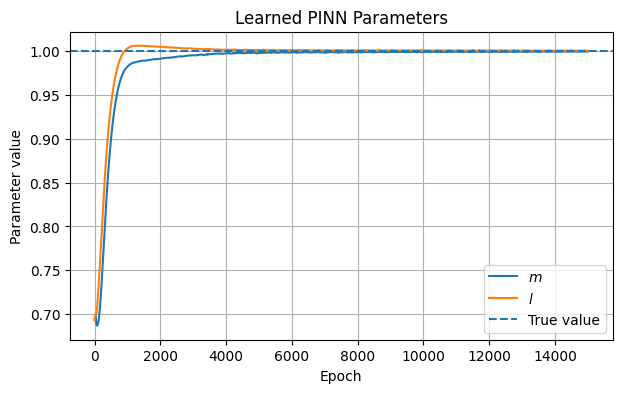

Learned m: 0.99940025806427
Learned l: 1.000319480895996
True m: 1.0
True l: 1.0
Learned ml: 0.9997195473541751
Learned ml^2: 1.0000389386509085


In [71]:
plt.figure(figsize=(7, 4))
plt.plot(m_history, label=r"$m$")
plt.plot(l_history, label=r"$l$")
plt.axhline(1.0, linestyle="--", label="True value")
plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("Learned PINN Parameters")
plt.legend()
plt.grid(True)
plt.show()

m_learned, l_learned = pinn.parameters_physical()

m_learned = m_learned.item()
l_learned = l_learned.item()

print("Learned m:", m_learned)
print("Learned l:", l_learned)
print("True m:", 1.0)
print("True l:", 1.0)
print("Learned ml:", m_learned * l_learned)
print("Learned ml^2:", m_learned * l_learned**2)

In [72]:
def stormer_verlet_rollout(x0, steps, h, m, l, g=1.0):
    """
    Störmer-Verlet rollout for pendulum.
    x0 is [p_theta, theta].
    Returns array with shape (steps+1, 2).
    """
    
    xs = [x0.copy()]
    
    p = float(x0[0])
    theta = float(x0[1])
    
    for _ in range(steps):
        # half-step momentum update
        p_half = p - 0.5 * h * m * g * l * np.sin(theta)
        
        # full-step position update
        theta_new = theta + h * p_half / (m * l ** 2)
        
        # another half-step momentum update
        p_new = p_half - 0.5 * h * m * g * l * np.sin(theta_new)
        
        p = p_new
        theta = theta_new
        
        xs.append(np.array([p, theta]))
    
    return np.array(xs)

In [73]:
# Start from same initial point as the full trajectory
x0_pinn = data[0]

# Roll out for 139 steps to match full data length 140
pinn_sv_rollout = stormer_verlet_rollout(
    x0=x0_pinn,
    steps=len(data)-1,
    h=h,
    m=m_learned,
    l=l_learned,
    g=1.0
)

print("PINN Störmer-Verlet rollout shape:", pinn_sv_rollout.shape)
print("True data shape:", data.shape)

PINN Störmer-Verlet rollout shape: (140, 2)
True data shape: (140, 2)


Mean PINN SV rollout MSE: 1.4471665536802915e-06
Final PINN SV rollout MSE: 2.288581643703714e-06


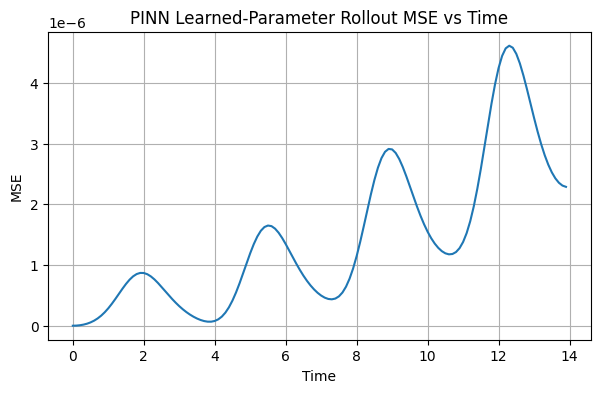

In [74]:
pinn_sv_mse_time = np.mean((pinn_sv_rollout - data) ** 2, axis=1)

print("Mean PINN SV rollout MSE:", pinn_sv_mse_time.mean())
print("Final PINN SV rollout MSE:", pinn_sv_mse_time[-1])

plt.figure(figsize=(7, 4))
plt.plot(t_full, pinn_sv_mse_time)
plt.xlabel("Time")
plt.ylabel("MSE")
plt.title("PINN Learned-Parameter Rollout MSE vs Time")
plt.grid(True)
plt.show()

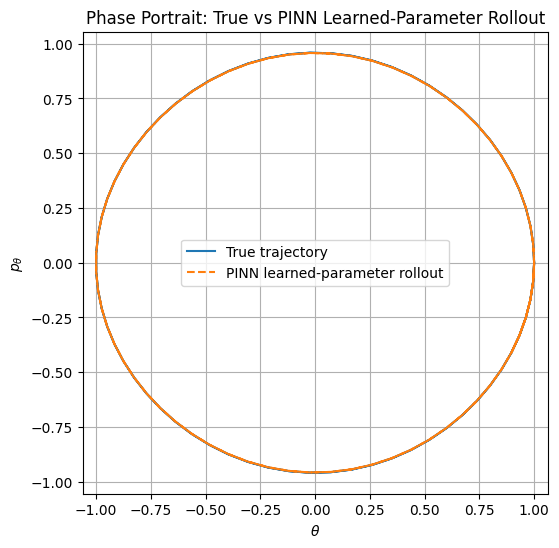

In [75]:
plt.figure(figsize=(6, 6))

plt.plot(data[:, 1], data[:, 0], label="True trajectory")
plt.plot(pinn_sv_rollout[:, 1], pinn_sv_rollout[:, 0], "--", label="PINN learned-parameter rollout")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Phase Portrait: True vs PINN Learned-Parameter Rollout")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

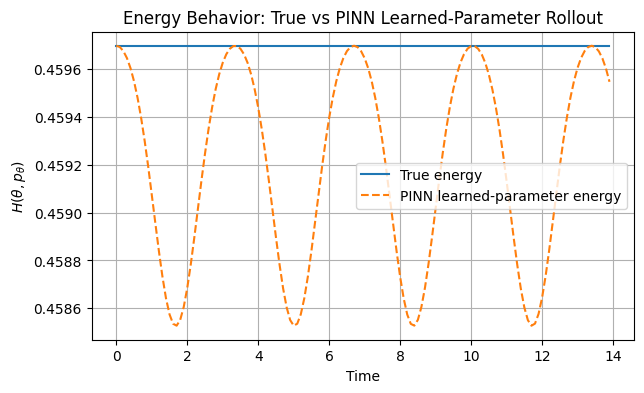

True energy range: 1.6764367671839864e-14
PINN rollout energy range: 0.0011708465315202199
PINN final energy error: 0.00015083951052241584


In [76]:
H_pinn_sv = energy(pinn_sv_rollout)

plt.figure(figsize=(7, 4))
plt.plot(t_full, H, label="True energy")
plt.plot(t_full, H_pinn_sv, "--", label="PINN learned-parameter energy")
plt.xlabel("Time")
plt.ylabel(r"$H(\theta,p_\theta)$")
plt.title("Energy Behavior: True vs PINN Learned-Parameter Rollout")
plt.ticklabel_format(useOffset=False, style="plain", axis="y")
plt.legend()
plt.grid(True)
plt.show()

print("True energy range:", H.max() - H.min())
print("PINN rollout energy range:", H_pinn_sv.max() - H_pinn_sv.min())
print("PINN final energy error:", abs(H_pinn_sv[-1] - H[0]))

In [77]:
sensitivity_cases = {
    "baseline": (m_learned, l_learned),
    "m +1%": (m_learned * 1.01, l_learned),
    "m -1%": (m_learned * 0.99, l_learned),
    "l +1%": (m_learned, l_learned * 1.01),
    "l -1%": (m_learned, l_learned * 0.99),
}

sensitivity_rollouts = {}
sensitivity_mse = {}

for name, (m_case, l_case) in sensitivity_cases.items():
    rollout = stormer_verlet_rollout(
        x0=x0_pinn,
        steps=len(data)-1,
        h=h,
        m=m_case,
        l=l_case,
        g=1.0
    )
    
    sensitivity_rollouts[name] = rollout
    sensitivity_mse[name] = np.mean((rollout - data) ** 2, axis=1)
    
    print(name)
    print("  m:", m_case)
    print("  l:", l_case)
    print("  mean MSE:", sensitivity_mse[name].mean())
    print("  final MSE:", sensitivity_mse[name][-1])

baseline
  m: 0.99940025806427
  l: 1.000319480895996
  mean MSE: 1.4471665536802915e-06
  final MSE: 2.288581643703714e-06
m +1%
  m: 1.0093942606449127
  l: 1.000319480895996
  mean MSE: 1.7506600428500198e-05
  final MSE: 1.8260877805859506e-05
m -1%
  m: 0.9894062554836273
  l: 1.000319480895996
  mean MSE: 2.8114918781528925e-05
  final MSE: 3.3503034113318613e-06
l +1%
  m: 0.99940025806427
  l: 1.0103226757049562
  mean MSE: 0.0006582721449482593
  final MSE: 0.001438529365214133
l -1%
  m: 0.99940025806427
  l: 0.9903162860870361
  mean MSE: 0.0007913259493435096
  final MSE: 0.0017009678683045915


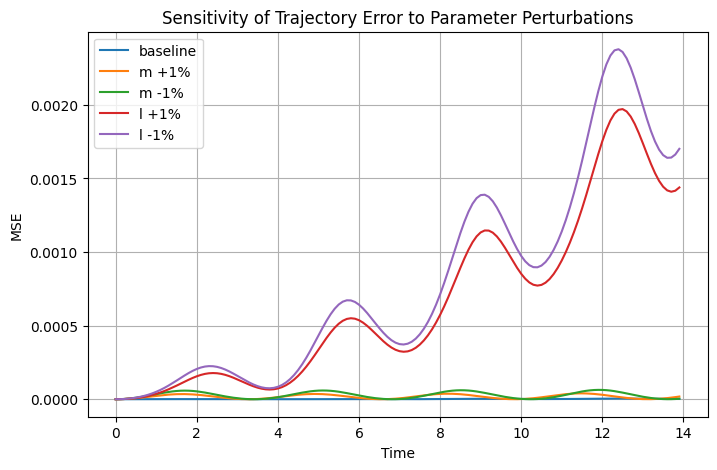

In [78]:
plt.figure(figsize=(8, 5))

for name, mse_values in sensitivity_mse.items():
    plt.plot(t_full, mse_values, label=name)

plt.xlabel("Time")
plt.ylabel("MSE")
plt.title("Sensitivity of Trajectory Error to Parameter Perturbations")
plt.legend()
plt.grid(True)
plt.show()

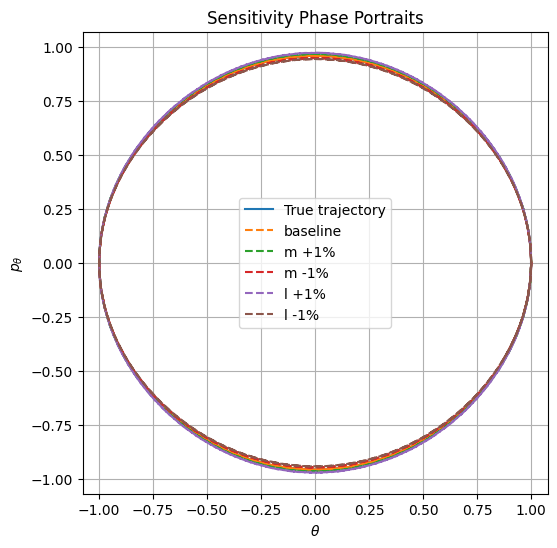

In [79]:
plt.figure(figsize=(6, 6))

plt.plot(data[:, 1], data[:, 0], label="True trajectory")

for name, rollout in sensitivity_rollouts.items():
    plt.plot(rollout[:, 1], rollout[:, 0], "--", label=name)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$p_\theta$")
plt.title("Sensitivity Phase Portraits")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# Task 3: PINN — Parameter Estimation and Identifiability

In this task, I used a Physics-Informed Neural Network to estimate the physical parameters $m$ and $l$ from the same training data, while keeping $g=1$ fixed. Unlike the FNN and SympNet, which directly learn a discrete map from one state to the next, the PINN learns a continuous-time representation of the trajectory,

$$
t \mapsto (p_{\theta}(t),\theta(t)).
$$

The PINN is trained using both data loss and physics loss. The data loss forces the neural network output to match the observed training trajectory. The physics loss forces the predicted trajectory to satisfy the pendulum equations,

$$
\frac{dp_{\theta}}{dt}=-mgl\sin\theta,
$$

and

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

Since $g=1$ is fixed in this project, the equations become

$$
\frac{dp_{\theta}}{dt}=-ml\sin\theta,
$$

and

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

The PINN loss is therefore composed of two parts:

$$
\mathcal{L}
=
\mathcal{L}_{data}
+
\mathcal{L}_{physics}.
$$

The data loss is

$$
\mathcal{L}_{data}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left\|
\hat{x}(t_i)-x_i
\right\|^2,
$$

where

$$
x_i =
\begin{bmatrix}
p_{\theta,i} \\
\theta_i
\end{bmatrix}.
$$

The physics loss is based on the residuals

$$
r_p =
\frac{d\hat{p}_{\theta}}{dt}
+
ml\sin(\hat{\theta}),
$$

and

$$
r_{\theta}
=
\frac{d\hat{\theta}}{dt}
-
\frac{\hat{p}_{\theta}}{ml^2}.
$$

Thus,

$$
\mathcal{L}_{physics}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
r_p(t_i)^2+r_{\theta}(t_i)^2
\right).
$$

The parameters $m$ and $l$ are learned together with the neural network weights.

## Identifiability of $m$ and $l$

The governing equations are

$$
\frac{dp_{\theta}}{dt}=-mgl\sin\theta,
$$

and

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

Since $g=1$, these become

$$
\frac{dp_{\theta}}{dt}=-ml\sin\theta,
$$

and

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

Therefore, the first equation depends on the parameter combination

$$
ml,
$$

while the second equation depends on the parameter combination

$$
ml^2.
$$

If both $\theta(t)$ and $p_{\theta}(t)$ are observed, then these two combinations can in principle be estimated from the trajectory. Let

$$
A=ml
$$

and

$$
B=ml^2.
$$

Then

$$
\frac{B}{A}
=
\frac{ml^2}{ml}
=
l.
$$

So,

$$
l=\frac{B}{A}.
$$

Once $l$ is known, $m$ can be recovered from

$$
m=\frac{A}{l}.
$$

Therefore, when both $\theta(t)$ and $p_{\theta}(t)$ are observed and $g$ is fixed, $m$ and $l$ are individually identifiable in principle.

However, this identifiability depends on observing both state variables. If only $\theta(t)$ were observed, or if the data were noisy or too short, it might be much harder to estimate $m$ and $l$ separately. In that case, the model might identify only certain combinations of the parameters more reliably than the individual parameters.

## Learned Parameters

After training, the PINN learned the following parameters:

$$
m = 0.9994002581,
$$

and

$$
l = 1.0003194809.
$$

The true nondimensionalized values are

$$
m=1,
$$

and

$$
l=1.
$$

The learned parameters are very close to the true values. The learned parameter combinations are

$$
ml = 0.9997195474,
$$

and

$$
ml^2 = 1.0000389387.
$$

These are also very close to the true values

$$
ml=1,
$$

and

$$
ml^2=1.
$$

This supports the identifiability argument above: since both $\theta(t)$ and $p_{\theta}(t)$ are observed, the PINN can recover both parameter combinations accurately, and therefore recover $m$ and $l$ individually.

## Rollout with Learned Parameters

After estimating $m$ and $l$, I used the learned parameters in a Störmer-Verlet integrator to simulate the pendulum trajectory forward in time. The Störmer-Verlet method is appropriate here because it is a structure-preserving method for Hamiltonian systems.

The Störmer-Verlet update is

$$
p_{n+\frac{1}{2}}
=
p_n
-
\frac{h}{2}mgl\sin(\theta_n),
$$

$$
\theta_{n+1}
=
\theta_n
+
h\frac{p_{n+\frac{1}{2}}}{ml^2},
$$

and

$$
p_{n+1}
=
p_{n+\frac{1}{2}}
-
\frac{h}{2}mgl\sin(\theta_{n+1}).
$$

Using the learned parameters, the mean rollout MSE is

$$
1.45 \times 10^{-6},
$$

and the final rollout MSE is

$$
2.29 \times 10^{-6}.
$$

These errors are very small. The phase portrait also shows that the PINN learned-parameter rollout almost overlaps with the true trajectory. This means that the learned parameters reproduce the long-time pendulum motion very accurately.

The energy behavior is also reasonable. The true energy range is

$$
1.67 \times 10^{-14},
$$

while the PINN learned-parameter rollout energy range is

$$
1.17 \times 10^{-3}.
$$

The final energy error is

$$
1.51 \times 10^{-4}.
$$

This energy variation is much larger than the true numerical energy variation, but it is still small compared with the FNN and SympNet energy errors. The small energy discrepancy is expected because the learned parameters are close to, but not exactly equal to, the true parameters.

## Sensitivity Experiment

To study the relationship between parameter error and trajectory error, I perturbed the learned parameters by $\pm 1\%$, one at a time, while holding the other parameter fixed. Then I integrated the system forward using the Störmer-Verlet method.

The baseline learned-parameter rollout has mean MSE

$$
1.45 \times 10^{-6},
$$

and final MSE

$$
2.29 \times 10^{-6}.
$$

When $m$ is increased by $1\%$, the mean MSE becomes

$$
1.75 \times 10^{-5},
$$

and the final MSE becomes

$$
1.83 \times 10^{-5}.
$$

When $m$ is decreased by $1\%$, the mean MSE becomes

$$
2.81 \times 10^{-5},
$$

and the final MSE becomes

$$
3.35 \times 10^{-6}.
$$

These errors are larger than the baseline, but still relatively small.

The effect of perturbing $l$ is much larger. When $l$ is increased by $1\%$, the mean MSE becomes

$$
6.83 \times 10^{-4},
$$

and the final MSE becomes

$$
1.44 \times 10^{-3}.
$$

When $l$ is decreased by $1\%$, the mean MSE becomes

$$
7.91 \times 10^{-4},
$$

and the final MSE becomes

$$
1.70 \times 10^{-3}.
$$

Therefore, the long-time trajectory is much more sensitive to perturbations in $l$ than to perturbations in $m$.

This makes sense from the equations. The parameter $l$ appears in both equations:

$$
\frac{dp_{\theta}}{dt}=-ml\sin\theta,
$$

and

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

In particular, $l$ appears quadratically in the denominator of the angular velocity equation. Therefore, a small change in $l$ changes the oscillation frequency and causes phase error to accumulate over time.

## Parameter Error vs. Trajectory Error

The sensitivity experiment shows that small parameter errors can produce much larger long-time trajectory errors. This is because trajectory error accumulates over time in a dynamical system.

A parameter error is a static error in the learned physical constants, such as

$$
m \neq 1
$$

or

$$
l \neq 1.
$$

A trajectory error is the accumulated difference between the simulated path and the true path over time:

$$
\left\|
\hat{x}(t)-x(t)
\right\|^2.
$$

Even if the parameter error is only $1\%$, it can change the period of oscillation. Once the predicted trajectory becomes slightly out of phase with the true trajectory, the pointwise MSE can grow over time even if the phase portrait still looks geometrically similar.

This explains why the sensitivity phase portraits remain close to the true closed orbit, while the MSE curves still increase over time. The trajectories are still physically reasonable, but they reach different points on the orbit at slightly different times.

Overall, the PINN performs very well in this task. It accurately recovers $m$ and $l$, produces a very small rollout MSE when integrated with the learned parameters, and demonstrates that even small parameter perturbations can lead to larger long-time trajectory errors through accumulated phase error.

# Task 4: Comparative Analysis

This project compares three different approaches for learning the pendulum dynamics: FNN, SympNet, and PINN. These methods differ not only in prediction accuracy, but also in the type of assumptions they impose on the learned dynamics.

## Comparison of FNN, SympNet, and PINN

The FNN has the weakest modeling bias. It directly learns the discrete map

$$
x_i \mapsto x_{i+1}
$$

from data, where

$$
x_i =
\begin{bmatrix}
p_{\theta,i} \\
\theta_i
\end{bmatrix}.
$$

Because it is a general feedforward neural network, it is very flexible. However, this flexibility also means that it does not automatically preserve energy, symplectic structure, or phase-space geometry. In my experiment, the FNN achieved a low teacher-forcing MSE,

$$
1.66 \times 10^{-5},
$$

but its rollout energy range was

$$
4.82 \times 10^{-2}.
$$

This shows that the FNN learned the local one-step map, but it did not preserve the Hamiltonian invariant of the system.

The SympNet has a stronger inductive bias than the FNN. It is designed to preserve symplectic structure. For a discrete map

$$
\Phi:x_i \mapsto x_{i+1},
$$

symplecticity means

$$
D\Phi(x)^TJD\Phi(x)=J.
$$

This structure is appropriate for Hamiltonian systems such as the pendulum. In my experiment, the SympNet had better energy behavior than the FNN. Its rollout energy range was

$$
1.47 \times 10^{-2},
$$

which is smaller than the FNN energy range. However, its mean rollout MSE was

$$
4.34 \times 10^{-3},
$$

which was worse than the FNN mean rollout MSE,

$$
2.83 \times 10^{-4}.
$$

This shows that SympNet improved geometric and energy consistency, but did not necessarily improve pointwise phase accuracy.

The PINN has the strongest physical modeling bias. Instead of only learning the next state, it uses the governing differential equations directly:

$$
\frac{dp_{\theta}}{dt}=-mgl\sin\theta,
$$

$$
\frac{d\theta}{dt}=\frac{p_{\theta}}{ml^2}.
$$

The PINN estimates the physical parameters $m$ and $l$ while enforcing the equation residuals. In my experiment, the PINN learned

$$
m=0.9994002581,
$$

and

$$
l=1.0003194809,
$$

which are very close to the true values

$$
m=1,\qquad l=1.
$$

Using these learned parameters in a Störmer-Verlet integrator gave a mean rollout MSE of

$$
1.45 \times 10^{-6},
$$

which was much smaller than both the FNN and SympNet rollout errors. Therefore, for this dataset, the PINN gave the best long-time quantitative prediction.

## Ranking by Modeling Bias and Inductive Bias

In terms of modeling bias, the ranking from weakest to strongest is:

$$
\text{FNN} < \text{SympNet} < \text{PINN}.
$$

The FNN has the least bias because it only assumes that a neural network can approximate the map from one state to the next. The SympNet adds the assumption that the learned map should be symplectic. The PINN has the strongest bias because it assumes the exact form of the differential equations and only needs to estimate the physical parameters.

In terms of inductive bias for this pendulum problem, the ranking is also:

$$
\text{FNN} < \text{SympNet} < \text{PINN}.
$$

The FNN has no explicit physical inductive bias. The SympNet has a geometric inductive bias that matches Hamiltonian dynamics. The PINN has the strongest physics-based inductive bias because it directly uses the governing equations.

## Ranking by Data Efficiency

In terms of data efficiency, I would rank the models as:

$$
\text{PINN} > \text{SympNet} > \text{FNN}.
$$

The PINN is the most data-efficient because it does not need to learn the entire dynamics only from data. It uses the known physical equations as additional information. This allows it to recover accurate parameter values from only 40 training points.

The SympNet is more data-efficient than the FNN because its symplectic structure restricts the class of possible learned maps. This helps reduce physically unrealistic behavior.

The FNN is the least data-efficient because it must infer both the local dynamics and the long-time structure purely from data. With only 40 training points, the FNN can fit the training trajectory, but it has no guarantee of preserving the correct long-time physics.

## Ranking by Robustness to Distribution Shift

For robustness to distribution shift, such as a different initial condition, I would rank the models as:

$$
\text{PINN} > \text{SympNet} > \text{FNN}.
$$

The PINN should be the most robust if the learned parameters are accurate, because the same differential equations apply to other initial conditions. Once $m$ and $l$ are learned correctly, the model can be integrated from a new initial condition using the physical system.

The SympNet should be more robust than the FNN because it preserves symplectic structure. Even under a different initial condition, the learned map is constrained to behave like a Hamiltonian flow.

The FNN is the least robust because it is trained only on one trajectory. If the initial condition changes, the new trajectory may lie outside the region of phase space that the FNN saw during training. In that case, the FNN may extrapolate poorly.

## Does Stronger Physical Structure Always Improve Long-Time Prediction?

The experiments show that imposing stronger physical structure does not always improve every measure of long-time prediction.

The SympNet imposed stronger structure than the FNN by enforcing symplecticity. This improved energy behavior: the SympNet rollout energy range was

$$
1.47 \times 10^{-2},
$$

while the FNN rollout energy range was

$$
4.82 \times 10^{-2}.
$$

Therefore, SympNet better preserved the Hamiltonian energy behavior.

However, the SympNet did not improve rollout MSE. The SympNet mean rollout MSE was

$$
4.34 \times 10^{-3},
$$

while the FNN mean rollout MSE was

$$
2.83 \times 10^{-4}.
$$

This means the SympNet stayed closer to the correct energy level but had worse pointwise trajectory accuracy. A likely explanation is phase error. The SympNet may follow a physically reasonable orbit but move along the orbit at a slightly incorrect speed. This produces larger MSE even if the phase portrait looks geometrically good.

The PINN, however, did improve both physical consistency and rollout accuracy. Its mean Störmer-Verlet rollout MSE was

$$
1.45 \times 10^{-6},
$$

which was much smaller than both the FNN and SympNet errors. This happened because the PINN used the correct governing equations and only had to estimate the parameters $m$ and $l$.

Therefore, the conclusion is that physical structure helps when the structure is correct and well matched to the task, but stronger structure does not automatically guarantee lower rollout MSE. Different diagnostics measure different qualities: MSE measures pointwise accuracy, energy measures physical invariance, and the phase portrait measures geometric consistency.

## Which Method I Would Trust Most with Additive Noise

If the data contained additive noise, I would trust the PINN most, provided that the governing equations are known correctly. The reason is that the PINN does not simply interpolate noisy data. It also enforces the differential equation residuals:

$$
r_p =
\frac{d\hat{p}_{\theta}}{dt}
+
ml\sin(\hat{\theta}),
$$

$$
r_{\theta}
=
\frac{d\hat{\theta}}{dt}
-
\frac{\hat{p}_{\theta}}{ml^2}.
$$

This physics loss acts like a regularizer. It discourages the network from fitting random noise that violates the known pendulum dynamics.

The FNN would be less reliable with noisy data because it may learn a noisy one-step map. During rollout, small noise-induced errors could accumulate quickly. The SympNet would be more robust than the FNN because it still preserves symplectic structure, but it does not directly use the differential equations or estimate interpretable physical parameters.

A concrete modification to improve PINN robustness would be to use a noise-aware loss function. For example, instead of using only standard mean squared error for the data loss, I could use a weighted loss:

$$
\mathcal{L}
=
\lambda_{data}\mathcal{L}_{data}
+
\lambda_{physics}\mathcal{L}_{physics},
$$

with

$$
\lambda_{physics} > \lambda_{data}
$$

when the data are noisy. This would force the model to trust the physics more than the noisy observations.

Another modification would be to add regularization or smoothing to the learned trajectory. For example, I could penalize large unnecessary curvature in the neural network output or use early stopping based on validation physics residuals. This would reduce overfitting to noisy training points.

Overall, for noisy data, I would trust the PINN most because it combines data fitting with known physics. The physics equations provide a stabilizing constraint that helps separate the true dynamical signal from random measurement noise.